<a href="https://colab.research.google.com/github/OlhaZahrebelna/python_for_ds_task/blob/main/Zahrebelna_Olha_%22HW_2_5_Time_Series_Analysis_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.express as px

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

In [2]:
df = pd.read_csv('/content/train.csv')
df

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [4]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [5]:
df.set_index('date', inplace=True)
df.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



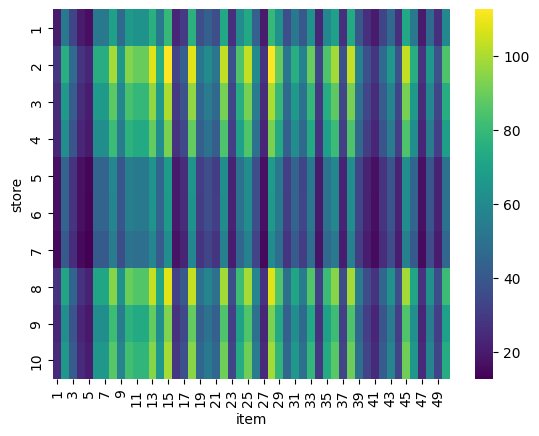

In [6]:
agg = df.groupby(['store','item'])['sales'].mean().unstack()

sns.heatmap(agg, cmap='viridis');

Середні продажі суттєво варіюються між товарами, що свідчить про гетерогенність попиту на рівні item.
Спостерігається стабільний патерн продажів між магазинами: товари з високим попитом залишаються такими у всіх магазинах.
Водночас, рівень продажів систематично відрізняється між групами магазинів, що вказує на store-specific effects (локація, розмір, трафік).

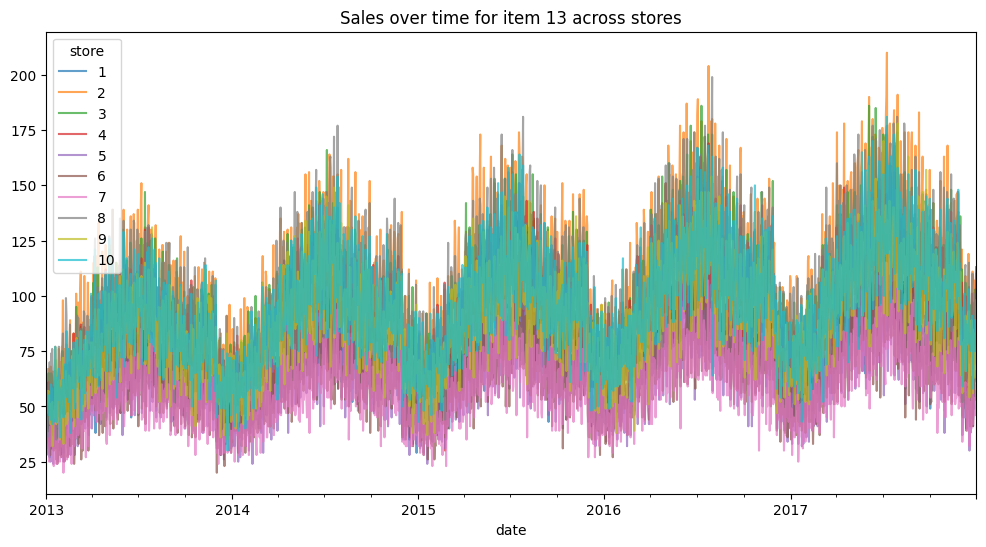

In [7]:
item_id = 13

subset = df[df['item'] == item_id]

pivot = subset.pivot_table(
    values='sales',
    index='date',
    columns='store'
)

pivot.plot(figsize=(12,6), alpha=0.7)
plt.title(f"Sales over time for item {item_id} across stores");

/tmp/ipykernel_95857/4062891565.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


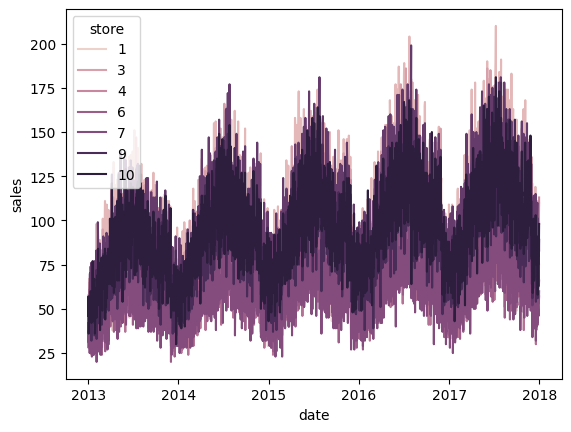

In [8]:
sns.lineplot(
    data=subset,
    x='date',
    y='sales',
    hue='store',
    estimator='mean',
    ci='sd'  # або 95
);


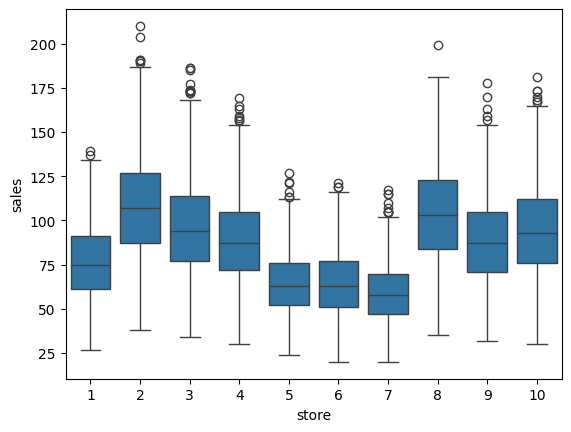

In [9]:
sns.boxplot(
    data=subset,
    x='store',
    y='sales'
);

Часовий ряд демонструє слабкий висхідний тренд, що свідчить про поступове зростання попиту з часом.
Присутня виражена сезонність із річним періодом, яка проявляється у регулярних піках і спадах, що повторюються щороку.
Амплітуда сезонних коливань зростає разом із рівнем ряду, що вказує на multiplicative seasonal structure.
Динаміка продажів є узгодженою між магазинами: всі ряди мають подібну форму, але відрізняються за рівнем (store-specific scaling).
Залишкова компонента присутня, але не домінує, що свідчить про відносно стабільну стохастичну складову.

In [10]:
store_stats = df.groupby('store')['sales'].agg(['mean','std'])

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
store_stats['cluster'] = kmeans.fit_predict(store_stats[['mean']])

In [12]:
store_stats.sort_values('mean')

,mean,std,cluster
store,,,
7,36.363735,18.684825,1
6,39.733516,20.310451,1
5,39.770164,20.365757,1
1,47.268379,24.006252,2
4,54.902946,27.733097,0
9,55.049025,27.832186,0
10,58.709288,29.554994,0
3,59.530602,29.974102,0
8,64.142048,32.231751,0


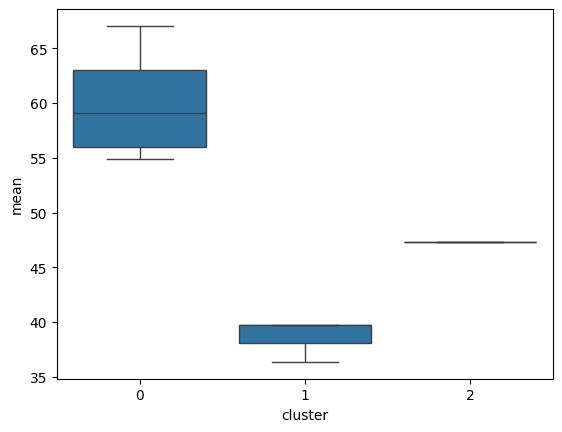

In [13]:
sns.boxplot(data=store_stats, x='cluster', y='mean');

Було виявлено, що магазини мають подібну часову динаміку, але відрізняються за рівнем продажів.
Для формалізації цього спостереження було проведено кластеризацію магазинів за середнім рівнем продажів.
В результаті виділено 3 групи:
магазини з низьким рівнем попиту
середнім
високим
Це підтверджує наявність store-specific level effects, які не впливають на форму часових рядів, але визначають їх масштаб.
Вважаю доцільним кластеризувати по формі ряду (через нормалізацію) і перевірити скільки класів нам потрібно для оптимального та якісного аналізу.

In [14]:
from sklearn.metrics import silhouette_score

for k in range(2,6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(store_stats[['mean']])
    print(k, silhouette_score(store_stats[['mean']], labels))

2 0.679148339360132
3 0.5145323160841363
4 0.5858749469081588
5 0.6821781520040573


Для визначення оптимальної кількості кластерів було використано silhouette score.
Найвищі значення отримано для k=2 (0.679) та k=5 (0.682).
Однак при k=5 кількість об’єктів у вибірці є малою (10 магазинів), що призводить до надмірної фрагментації кластерів.
При k=2 кластери є добре розділеними та інтерпретованими.
Таким чином, було обрано 2 кластери.

In [15]:
kmeans = KMeans(n_clusters=2, random_state=42)
store_stats['cluster'] = kmeans.fit_predict(store_stats[['mean']])

In [16]:
store_stats.sort_values('mean')

,mean,std,cluster
store,,,
7,36.363735,18.684825,1
6,39.733516,20.310451,1
5,39.770164,20.365757,1
1,47.268379,24.006252,1
4,54.902946,27.733097,0
9,55.049025,27.832186,0
10,58.709288,29.554994,0
3,59.530602,29.974102,0
8,64.142048,32.231751,0


In [17]:
df_low = df[df['store'].isin([1,5,6,7])]
df_hv  = df[df['store'].isin([2,3,4,8,9,10])]

In [18]:
df_hv.head(5)

,store,item,sales
date,,,
2013-01-01,2,1,12
2013-01-02,2,1,16
2013-01-03,2,1,16
2013-01-04,2,1,20
2013-01-05,2,1,16


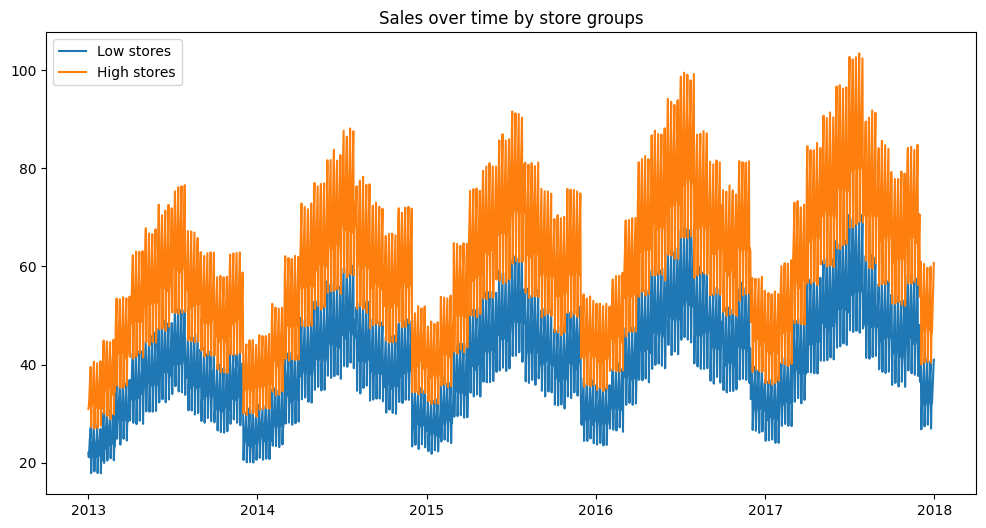

In [19]:
low_ts = df_low.groupby('date')['sales'].mean()
high_ts = df_hv.groupby('date')['sales'].mean()

plt.figure(figsize=(12,6))
plt.plot(low_ts, label='Low stores')
plt.plot(high_ts, label='High stores')
plt.legend()
plt.title('Sales over time by store groups')
plt.show()

Загальний висновок:
Дані мають панельну структуру (store × item × date). Продажі розподілені нерівномірно між товарами — існує чітка різниця між популярними та менш популярними позиціями. Часовий ряд є регулярним (без пропусків), що робить його придатним для класичних методів аналізу часових рядів.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [20]:
df_i1s1 = df[(df['item'] == 1) & (df['store'] == 1)].copy()

In [21]:
df_i1s1.head(5)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10


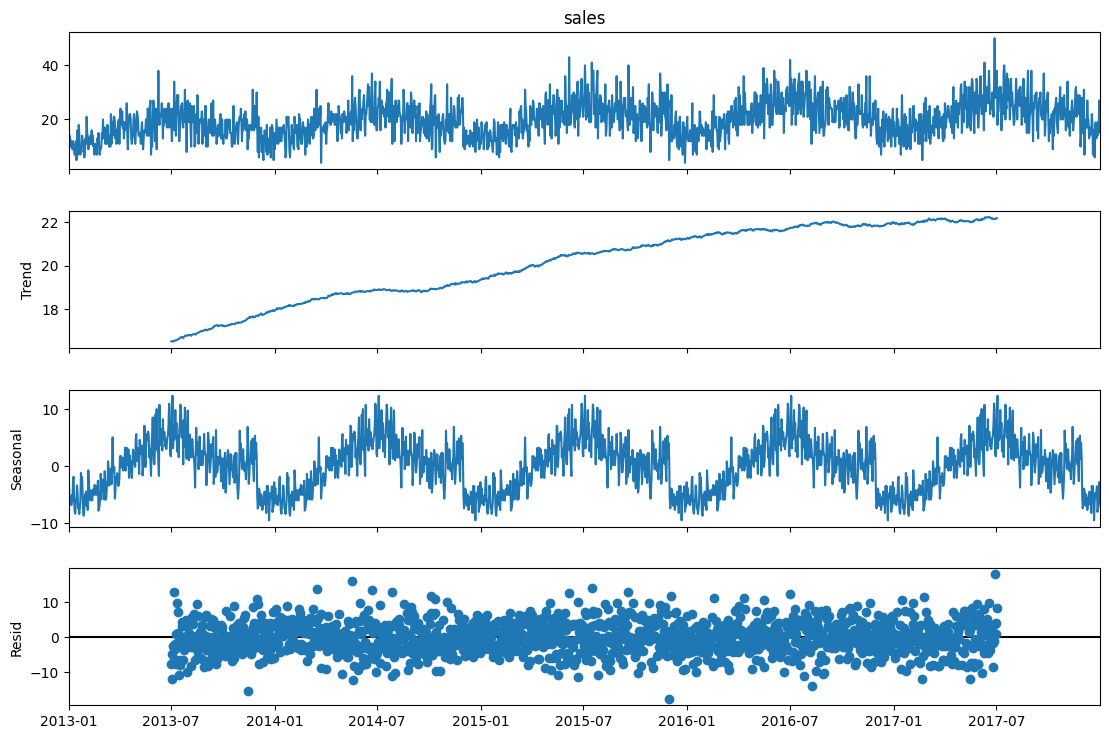

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(df_i1s1['sales'], model='additive', period=365)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

Адитивна декомпозиція з періодом 365 показала наявність висхідного тренду та річної сезонності. Водночас у залишках спостерігається певна структура, що може свідчити про наявність додаткових сезонних компонент (наприклад, тижневої), які не враховуються цією моделлю.

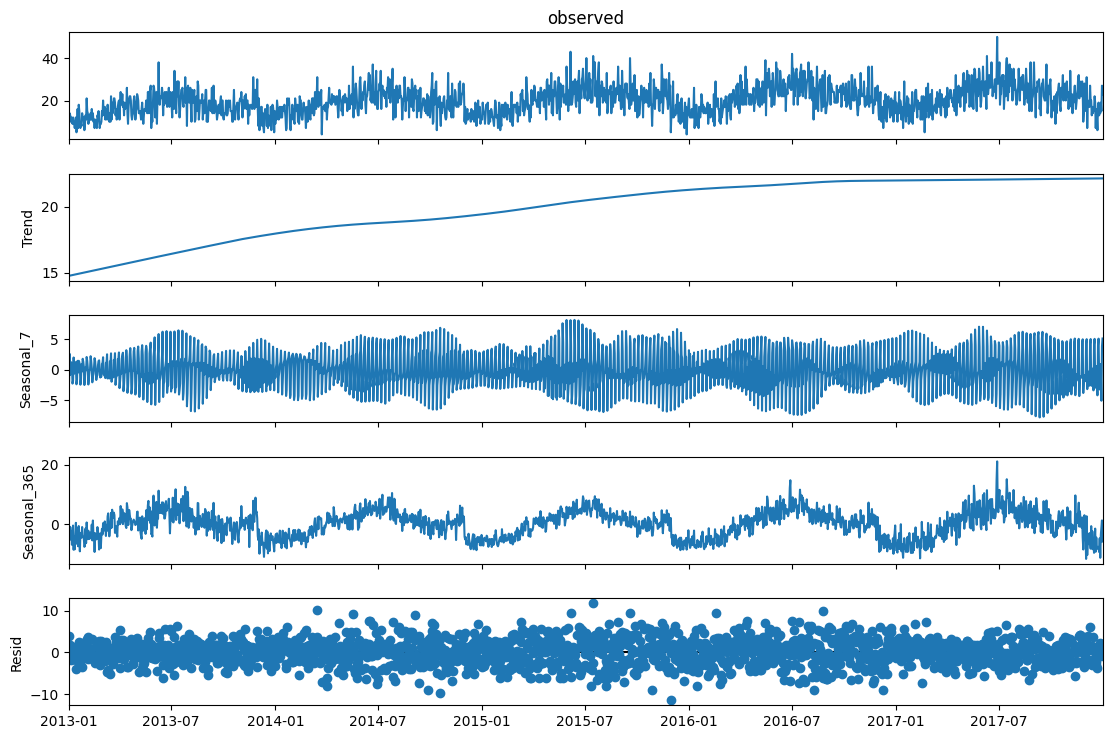

In [23]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(df_i1s1['sales'], periods=[7, 365])
res = mstl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
plt.show()

Було застосовано мультисезонну декомпозицію (MSTL) з періодами 7 та 365. Результати показали наявність як тижневої, так і річної сезонності. У порівнянні з однофакторною декомпозицією, MSTL дозволила краще відокремити сезонні компоненти, що підтверджується відсутністю структури у залишках

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [24]:
!pip install darts --quiet

In [25]:
from darts import TimeSeries

series = TimeSeries.from_dataframe(df_i1s1, value_cols='sales')
series

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-12-27,14.0
2017-12-28,19.0
2017-12-29,15.0


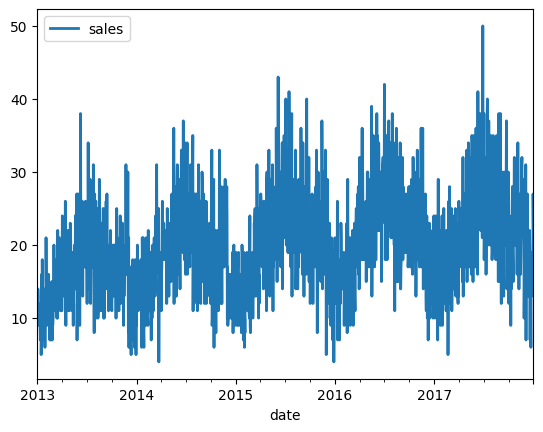

In [26]:
series.plot()
plt.show();

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

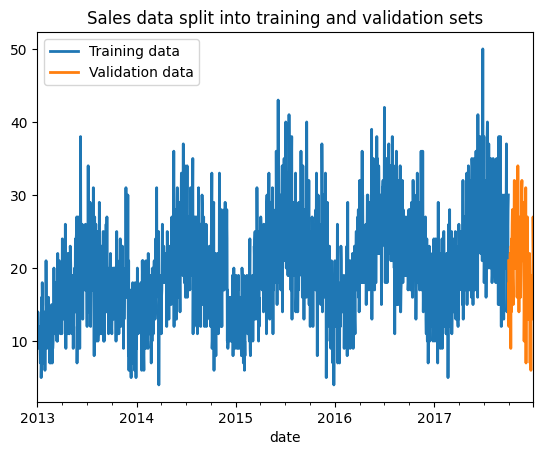

In [27]:
train, val= series.split_before(pd.Timestamp('2017-10-01'))
train.plot(label='Training data')
val.plot(label='Validation data')
plt.title('Sales data split into training and validation sets')
plt.legend()
plt.show();

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1000x600 with 0 Axes>

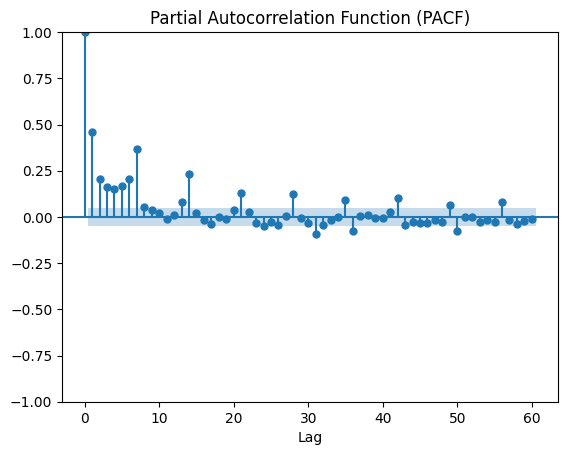

In [28]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

train_np = train.values().flatten()

plt.figure(figsize=(10, 6))
plot_pacf(train_np, lags=60, method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lag')
plt.show();

Часткова автокореляційна функція показує, що найбільш значущими є лаги 1–3, що свідчить про сильну залежність поточних значень ряду від попередніх. Також спостерігається пік на лагу 7, що підтверджує наявність тижневої сезонності. Подальші лаги мають незначний вплив, оскільки їх значення знаходяться в межах довірчого інтервалу.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

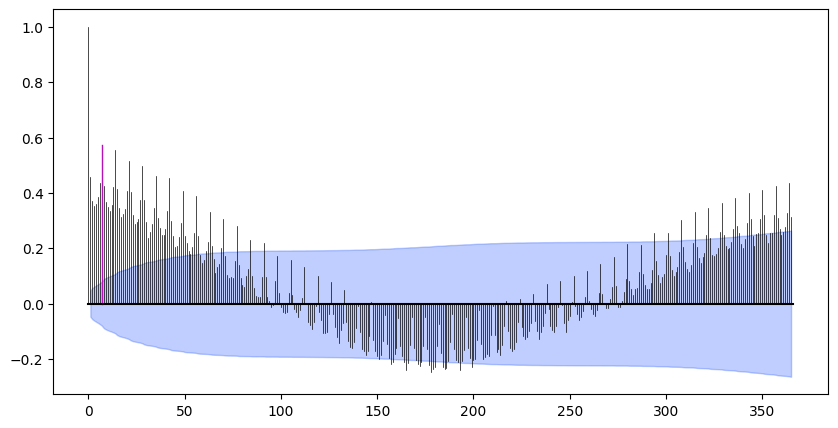

m=7: seasonal=True, detected_period=7
m=365: seasonal=False, detected_period=365


In [29]:
from darts.utils.statistics import check_seasonality, plot_acf
import matplotlib.pyplot as plt

plot_acf(train, m=7, alpha=0.05, max_lag=365)
plt.show()

for m in [7, 365]:
    current_max_lag = m if m == 365 else 100
    if m == 365:
        current_max_lag = 365
    else:
        current_max_lag = 365

    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05, max_lag=current_max_lag)
    print(f"m={m}: seasonal={is_seasonal}, detected_period={period}")

Перевірка за допомогою функції check_seasonality() показала наявність тижневої сезонності (m=7), що підтверджується значущими значеннями автокореляції. Для m=365 сезонність формально не була виявлена, що може бути пов’язано зі слабшою або менш стабільною річною сезонністю. Водночас попередній аналіз (декомпозиція) вказує на її можливу наявність.

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [30]:
!pip install pytorch-lightning --quiet
from darts.models import NaiveSeasonal

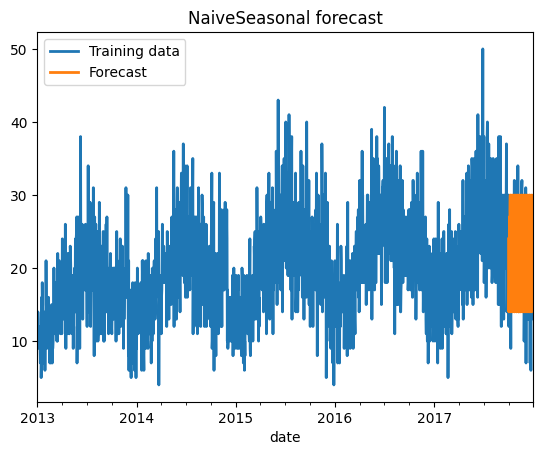

In [31]:
model_NS = NaiveSeasonal(K=7)
model_NS.fit(train)
forecast_NS = model_NS.predict(len(val))

series.plot(label='Training data')
forecast_NS.plot(label='Forecast')
plt.title('NaiveSeasonal forecast')
plt.legend()
plt.show();

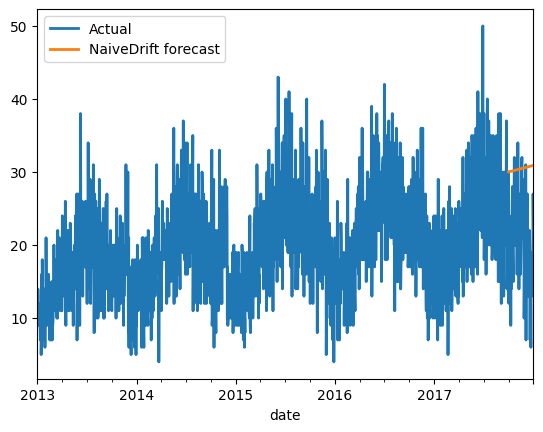

In [32]:
from darts.models import NaiveDrift

model_ND = NaiveDrift()
model_ND.fit(train)
forecast_ND = model_ND.predict(len(val))

series.plot(label='Actual')
forecast_ND.plot(label='NaiveDrift forecast')
plt.legend()
plt.show();

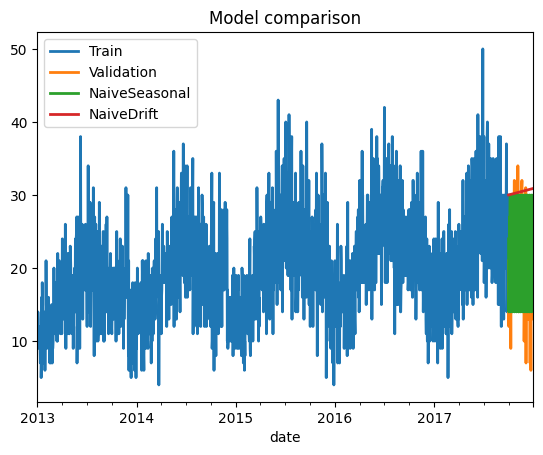

In [33]:
train.plot(label='Train')
val.plot(label='Validation')

forecast_NS.plot(label='NaiveSeasonal')
forecast_ND.plot(label='NaiveDrift')

plt.legend()
plt.title('Model comparison')
plt.show();

Для даного ряду, де присутня виражена тижнева сезонність, модель NaiveSeasonal є значно більш адекватною, ніж NaiveDrift. Це підтверджує, що врахування сезонності є критично важливим для побудови точного прогнозу.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [34]:
from darts.metrics import mae, rmse, mape

print("NaiveSeasonal MAE:", mae(val, forecast_NS))
print("NaiveSeasonal RMSE:", rmse(val, forecast_NS))
print("NaiveSeasonal MAPE:", mape(val, forecast_NS))

print("NaiveDrift MAE:", mae(val, forecast_ND))
print("NaiveDrift RMSE:", rmse(val, forecast_ND))
print("NaiveDrift MAPE:", mape(val, forecast_ND))

NaiveSeasonal MAE: 6.119565217391305
NaiveSeasonal RMSE: 7.399324293474371
NaiveSeasonal MAPE: 38.174845664426456
NaiveDrift MAE: 10.398360470659073
NaiveDrift RMSE: 11.80182038301019
NaiveDrift MAPE: 68.74405050496789


Значення MAPE показують, що модель NaiveSeasonal має середню відносну помилку близько 38%, тоді як NaiveDrift — близько 69%. Це свідчить про те, що NaiveSeasonal є значно точнішою моделлю, оскільки враховує сезонність даних. Проте обидві моделі мають досить високий рівень помилки, що вказує на необхідність використання більш складних моделей, які одночасно враховують тренд і сезонніст

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

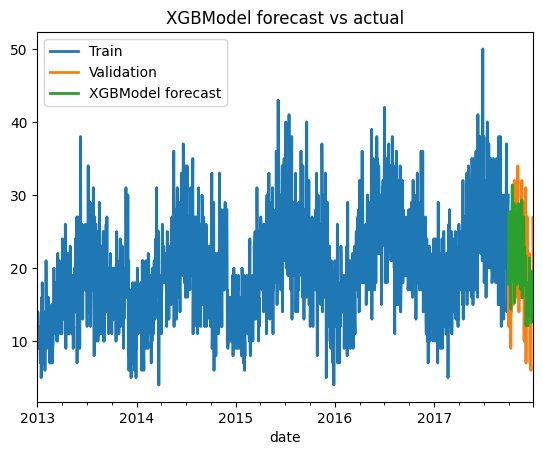

XGBModel MAE: 4.193086675975634
XGBModel RMSE: 4.957007368384354
XGBModel MAPE: 24.45892254620061

Baseline comparison:
NaiveSeasonal MAPE: 38.174845664426456
NaiveDrift MAPE: 68.74405050496789
XGBModel MAPE: 24.45892254620061

Висновок: XGBModel краща за NaiveSeasonal і значно краще враховує структуру ряду.


In [35]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mae, rmse, mape
import matplotlib.pyplot as plt

scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)


xgb_model = XGBModel(
    lags=30,
    lags_past_covariates=30,
    output_chunk_length=1,
    random_state=42,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    add_encoders={
        "datetime_attribute": {
            "past": ["year", "month", "day", "dayofweek", "dayofyear"]
        },
        "cyclic": {
            "past": ["month", "dayofweek", "dayofyear"]
        },
        "position": {"past": ["relative"]},
    }
)


xgb_model.fit(train_scaled)

forecast_scaled = xgb_model.predict(n=len(val))
forecast_xgb = scaler.inverse_transform(forecast_scaled)


train.plot(label='Train')
val.plot(label='Validation')
forecast_xgb.plot(label='XGBModel forecast')
plt.title('XGBModel forecast vs actual')
plt.legend()
plt.show()

xgb_mae = mae(val, forecast_xgb)
xgb_rmse = rmse(val, forecast_xgb)
xgb_mape = mape(val, forecast_xgb)

print("XGBModel MAE:", xgb_mae)
print("XGBModel RMSE:", xgb_rmse)
print("XGBModel MAPE:", xgb_mape)


ns_mape = mape(val, forecast_NS)
nd_mape = mape(val, forecast_ND)

print("\nBaseline comparison:")
print("NaiveSeasonal MAPE:", ns_mape)
print("NaiveDrift MAPE:", nd_mape)
print("XGBModel MAPE:", xgb_mape)

if xgb_mape < ns_mape:
    print("\nВисновок: XGBModel краща за NaiveSeasonal і значно краще враховує структуру ряду.")
elif xgb_mape < nd_mape:
    print("\nВисновок: XGBModel краща за NaiveDrift, але не перевершила NaiveSeasonal.")
else:
    print("\nВисновок: XGBModel поки не дає покращення, варто тюнити параметри та лаги.")

XGBModel є найбільш адекватною моделлю для цього часового ряду і суттєво перевершує базові підходи, тому її доцільно використовувати для фінального прогнозу.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

ExponentialSmoothing MAE: 5.369692149040884
ExponentialSmoothing RMSE: 6.618392166276072
ExponentialSmoothing MAPE: 36.6452638639309


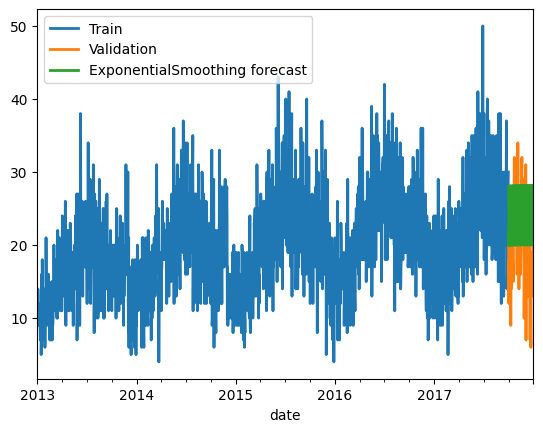

In [36]:
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode, SeasonalityMode

seasonal_periods = 7
model_exp = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE,
    seasonal=SeasonalityMode.ADDITIVE,
    seasonal_periods=seasonal_periods,
    damped=True)
model_exp.fit(train)
forecast = model_exp.predict(len(val))

train.plot(label='Train')
val.plot(label='Validation')
forecast.plot(label='ExponentialSmoothing forecast')

print("ExponentialSmoothing MAE:", mae(val, forecast))
print("ExponentialSmoothing RMSE:", rmse(val, forecast))
print("ExponentialSmoothing MAPE:", mape(val, forecast))

Exponential Smoothing є покращенням над базовими моделями, але не досягає точності більш складних підходів (таких як XGBoost), тому не є оптимальним вибором для фінального прогнозування

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


ARIMA MAE: 5.771332980013423
ARIMA RMSE: 7.020165144528745
ARIMA MAPE: 39.52818300569095


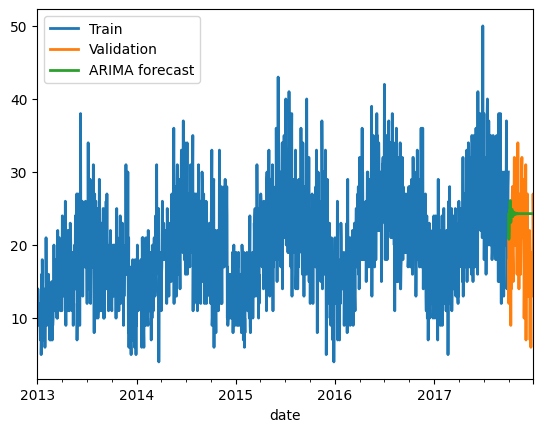

In [37]:
from darts.models import ARIMA

model_arima = ARIMA(p=7, d=1, q=1)
model_arima.fit(train)
forecast_arima = model_arima.predict(len(val))

train.plot(label='Train')
val.plot(label='Validation')
forecast_arima.plot(label='ARIMA forecast')

print("ARIMA MAE:", mae(val, forecast_arima))
print("ARIMA RMSE:", rmse(val, forecast_arima))
print("ARIMA MAPE:", mape(val, forecast_arima))

ARIMA у даній конфігурації не є оптимальною моделлю для цього ряду. Вона поступається як простішим сезонним підходам, так і більш складним моделям, що краще враховують сезонність і нелінійності.

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [38]:
!pip install statsforecast --quiet

AutoARIMA


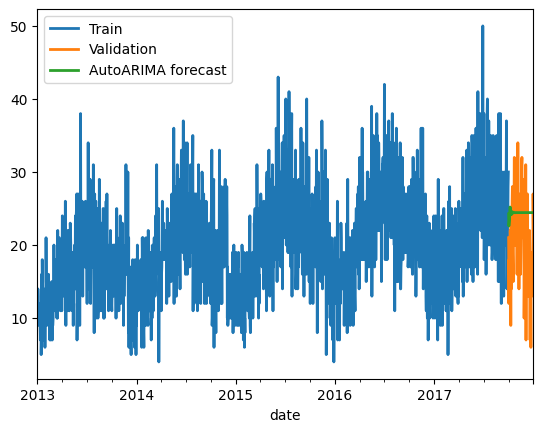

AutoARIMA MAE: 5.870337495388008
AutoARIMA RMSE: 7.130246379952478
AutoARIMA MAPE: 40.294072271660795


In [39]:
from darts.models import AutoARIMA

model_autoarima = AutoARIMA()
model_autoarima.fit(train)
print(model_autoarima.model)
forecast_autoarima = model_autoarima.predict(len(val))

train.plot(label='Train')
val.plot(label='Validation')
forecast_autoarima.plot(label='AutoARIMA forecast')
plt.legend()
plt.show()

print("AutoARIMA MAE:", mae(val, forecast_autoarima))
print("AutoARIMA RMSE:", rmse(val, forecast_autoarima))
print("AutoARIMA MAPE:", mape(val, forecast_autoarima))

Модель не здатна адекватно описати варіативність і локальні коливання, що помітно на валідаційній вибірці. Прогноз має згладжений характер, що вказує на недостатнє врахування сезонної або іншої складної структури даних.
Порівняно з попереднім експериментом, якість моделі не демонструє суттєвого покращення, що дозволяє зробити висновок про обмежену ефективність AutoARIMA для даного набору даних без додаткового налаштування

In [40]:
!pip install "u8darts[notorch]" statsforecast --quiet

14. Натренуйте модель Prophet та зробіть висновок про її якість.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet MAE: 3.827405695211528
Prophet RMSE: 4.634403721218822
Prophet MAPE: 23.804832095755977


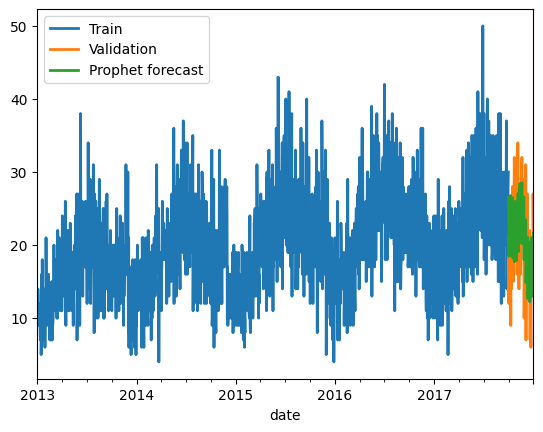

In [41]:
from darts.models import Prophet

model_prophet = Prophet()
model_prophet.fit(train)
forecast_prophet = model_prophet.predict(len(val))

train.plot(label='Train')
val.plot(label='Validation')
forecast_prophet.plot(label='Prophet forecast')

print("Prophet MAE:", mae(val, forecast_prophet))
print("Prophet RMSE:", rmse(val, forecast_prophet))
print("Prophet MAPE:", mape(val, forecast_prophet))

Prophet ефективно моделює як тренд, так і сезонність (вбудовані компоненти), тому добре відтворює структуру часового ряду та його коливання. Прогноз є більш гнучким і ближчим до фактичних значень.

Повідомлення про disabling daily seasonality означає, що модель автоматично визначила, що денна сезонність не є значущою для цього ряду.

Prophet є найкращою моделлю серед протестованих, оскільки забезпечує найменшу помилку прогнозу та найкраще враховує структуру даних. Її доцільно обрати як фінальну модель.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  133 K │ train │     0 │
│ 6 │ V               │ Linear           │     51 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 133 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 133 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

RNNModel MAE: 19.75751408546043
RNNModel RMSE: 20.588958799708486
RNNModel MAPE: 97.45607228246233


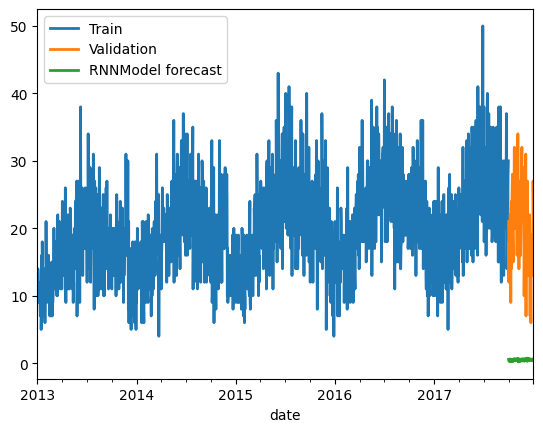

In [43]:
from darts.models import RNNModel

model = RNNModel(model='LSTM', input_chunk_length=24, output_chunk_length=1, hidden_dim=50, n_rnn_layers=7)
model.fit(train_scaled, verbose=True)
prediction = model.predict(len(val_scaled))

train.plot(label='Train')
val.plot(label='Validation')
prediction.plot(label='RNNModel forecast')

print("RNNModel MAE:", mae(val, prediction))
print("RNNModel RMSE:", rmse(val, prediction))
print("RNNModel MAPE:", mape(val, prediction))

У даній конфігурації RNNModel є неефективною і значно поступається як класичним статистичним моделям, так і сучасним підходам (XGBoost, Prophet). Її використання для цього завдання є недоцільним без додаткового налаштування.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU avai

Output()

RNNModel MAE: 5.158323529148513
RNNModel RMSE: 6.44445856122099
RNNModel MAPE: 31.34985010056514


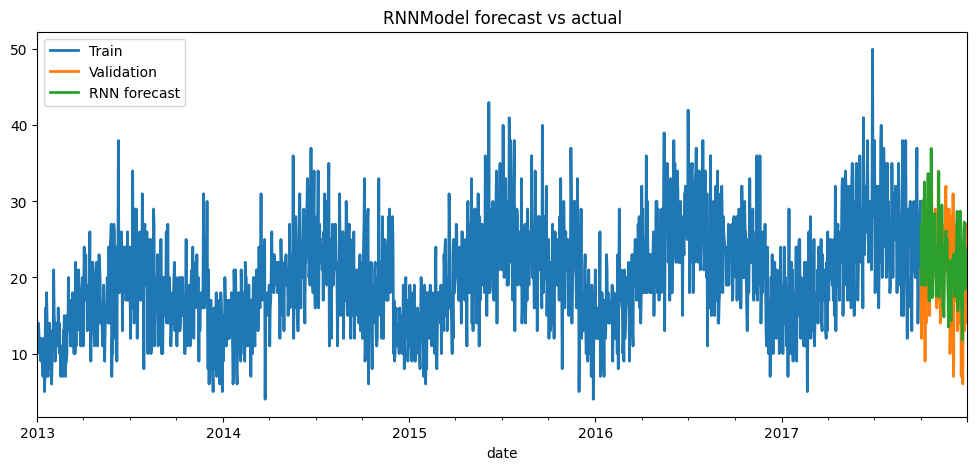

In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler = Scaler(MinMaxScaler())
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)

model_rnn = RNNModel(
    model="LSTM",
    input_chunk_length=30,
    training_length=40,
    hidden_dim=25,
    n_rnn_layers=2,
    dropout=0.1,
    batch_size=16,
    n_epochs=200,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42
)

# 3. Навчання
model_rnn.fit(train_scaled, verbose=False) # Changed verbose=True to verbose=False

# 4. Прогноз
forecast_scaled = model_rnn.predict(len(val))
forecast_rnn = scaler.inverse_transform(forecast_scaled)

# 5. Оцінка
print("RNNModel MAE:", mae(val, forecast_rnn))
print("RNNModel RMSE:", rmse(val, forecast_rnn))
print("RNNModel MAPE:", mape(val, forecast_rnn))

# 6. Графік
plt.figure(figsize=(12, 5))
train.plot(label="Train")
val.plot(label="Validation")
forecast_rnn.plot(label="RNN forecast")
plt.legend()
plt.title("RNNModel forecast vs actual")
plt.show()

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [47]:
hfcst = model_prophet.historical_forecasts(
    series=series,
    start=pd.Timestamp("2017-10-01"),
    forecast_horizon=30,
    stride=7,          # прогноз що тижня
    retrain=True,
    last_points_only=False,
    verbose=True
)

historical forecasts: 100%|██████████| 9/9 [00:03<00:00,  2.84it/s]


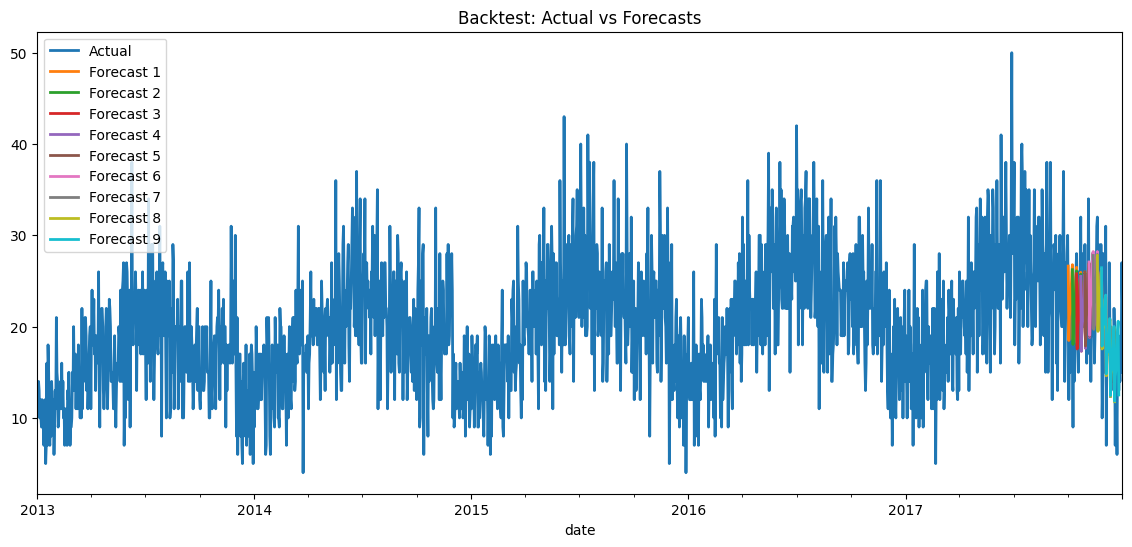

In [48]:
plt.figure(figsize=(14, 6))

series.plot(label="Actual")

for i, fc in enumerate(hfcst):
    fc.plot(label=f"Forecast {i+1}")

plt.title("Backtest: Actual vs Forecasts")
plt.legend()
plt.show()

historical forecasts: 100%|██████████| 9/9 [00:04<00:00,  2.08it/s]


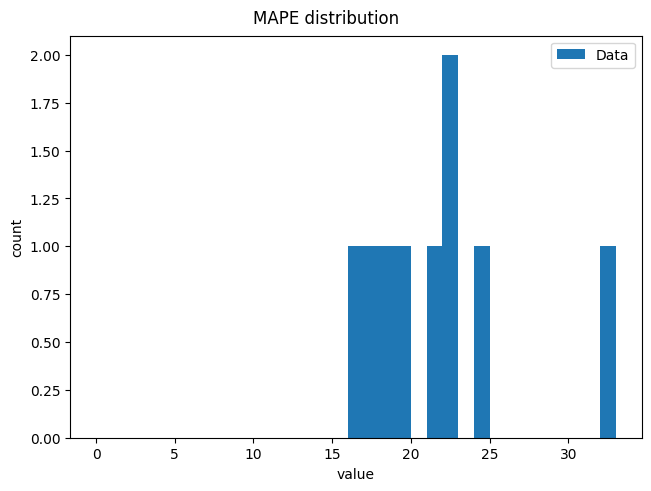

Mean MAPE: 21.81%


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from darts.metrics import mape
from darts.utils.statistics import plot_hist

error = model_prophet.backtest(
    series=series,
    start=pd.Timestamp("2017-10-01"),
    forecast_horizon=30,
    stride=7,   # ключова зміна
    retrain=True,
    metric=mape,
    reduction=None,
    verbose=True
)

plot_hist(
    error,
    bins=np.arange(0, max(error) + 1, 1),
    title="MAPE distribution"
)
plt.show()

mean_mape = np.mean(error)
print(f"Mean MAPE: {mean_mape:.2f}%")

Проведений бек-тест показав, що модель Prophet стабільно відтворює поведінку часового ряду на різних відрізках часу.

Середнє значення MAPE ≈ 21.81%, що:
є кращим або співставним з попередньою оцінкою (~23.8%)
підтверджує стабільність моделі на різних вікнах прогнозування


Модель демонструє стабільну якість прогнозу у часі, а не лише на одному train/validation split
Розподіл помилки (гістограма) показує, що більшість прогнозів мають помилку в межах ~15–25%, без значних викидів
Це свідчить про добру узагальнюючу здатність моделі


Поведінка моделі:
Prophet добре відслідковує тренд і сезонність
Прогнози залишаються близькими до реальних значень навіть при багаторазовому перекалібруванні (retrain=True)

Висновок:
Бек-тест підтвердив, що Prophet є надійною та стабільною моделлю для цього часового ряду, яка забезпечує узгоджену якість прогнозування в різні періоди часу. Її можна впевнено використовувати для практичного прогнозування

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Для задачі прогнозування продажів для 50 товарів у 10 магазинах недоцільно будувати окрему модель для кожного часового ряду через велику кількість моделей і ризик перенавчання. Аналіз показав, що всі ряди мають подібну структуру (тренд і сезонність), а основні відмінності полягають у масштабі продажів.
Тому найбільш ефективним підходом є використання глобальних моделей, які навчаються одразу на кількох рядах, із попередньою кластеризацією магазинів за рівнем попиту. Оптимально будувати 2–3 моделі для різних груп магазинів, що дозволяє врахувати різницю в масштабі та зберегти спільні патерни.
Серед моделей доцільно використовувати Prophet як базову, оскільки вона добре враховує тренд і сезонність, або більш складні підходи (наприклад, XGBoost) для підвищення точності.
Таким чином, запропонований підхід дозволяє зменшити складність задачі, покращити узагальнення моделей і ефективно використати спільну структуру часових рядів.